**1. Preparação e Inspeção Inicial dos Dados**
---


In [8]:
# @title
print("Primeiras 5 linhas do DataFrame com falhas (failures_df):")
display(failures_df.head())

print("\nPrimeiras 5 linhas do DataFrame sem falhas (no_failures_df):")
display(no_failures_df.head())

Primeiras 5 linhas do DataFrame com falhas (failures_df):


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,Power Failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,Power Failure
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,Tool Wear Failure
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,Overstrain Failure
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,Overstrain Failure



Primeiras 5 linhas do DataFrame sem falhas (no_failures_df):


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


**2. Estatisticas Descritivas (Variância)**
---

In [12]:
# @title
import pandas as pd

# Define the numerical features to analyze for variance
numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Tool wear [min]'
]

# Calculate the variance for each feature in the failures_df group
variance_failures = failures_df[numerical_features].var().rename('Falha').to_frame()

# Calculate the variance for each feature in the no_failures_df group
variance_no_failures = no_failures_df[numerical_features].var().rename('Sem Falha').to_frame()

# Combine the variances into a single DataFrame for comparison
variance_comparison_df_final = pd.concat([variance_failures, variance_no_failures], axis=1)

print("Comparação da Variância das Variáveis Críticas:")
display(variance_comparison_df_final)

Comparação da Variância das Variáveis Críticas:


,Falha,Sem Falha
Air temperature [K],4.225071,3.963828
Process temperature [K],1.897935,2.208993
Rotational speed [rpm],144511.655139,28037.022623
Tool wear [min],5304.219443,3960.737539


**3. Análise de Correlação**
---

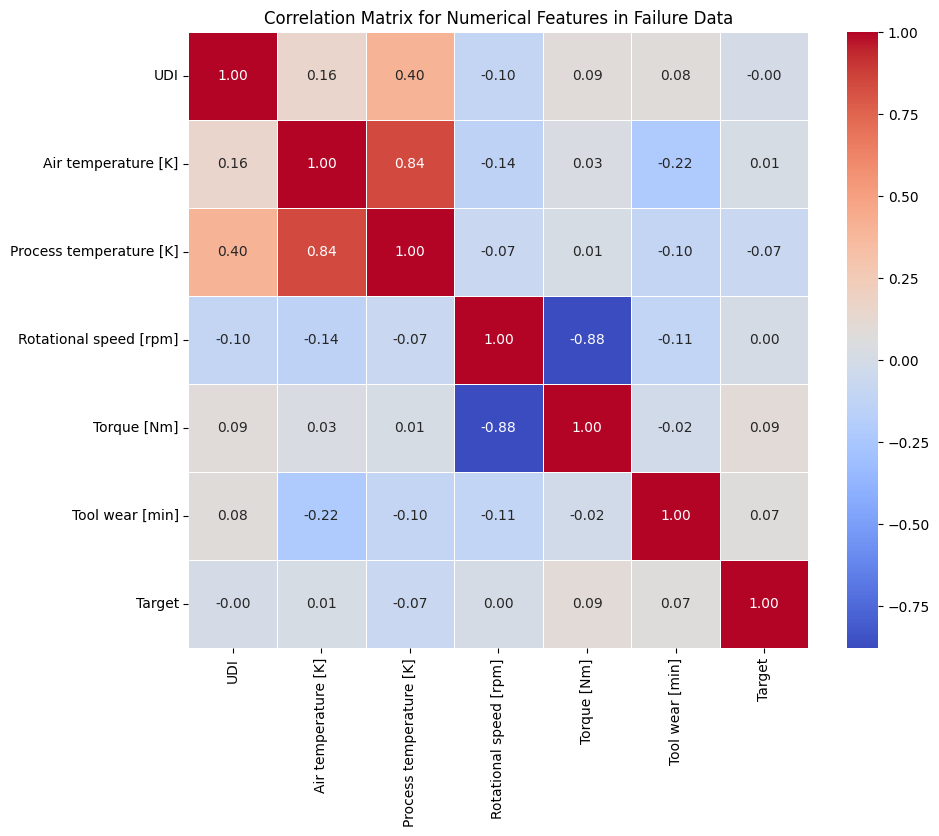

In [6]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns from the failures_df for correlation analysis
numerical_failures_df = failures_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_failures_df.corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix for Numerical Features in Failure Data')
plt.show()


**4. Análise de Outliers**
---

/tmp/ipykernel_7915/135313828.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Failure Status', y=feature, data=combined_df_outliers, ax=axes[i], palette={'Com Falha': 'red', 'Sem Falha': 'green'})
/tmp/ipykernel_7915/135313828.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Failure Status', y=feature, data=combined_df_outliers, ax=axes[i], palette={'Com Falha': 'red', 'Sem Falha': 'green'})
/tmp/ipykernel_7915/135313828.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Failure Status', y=feature, data=combined_df_outlie

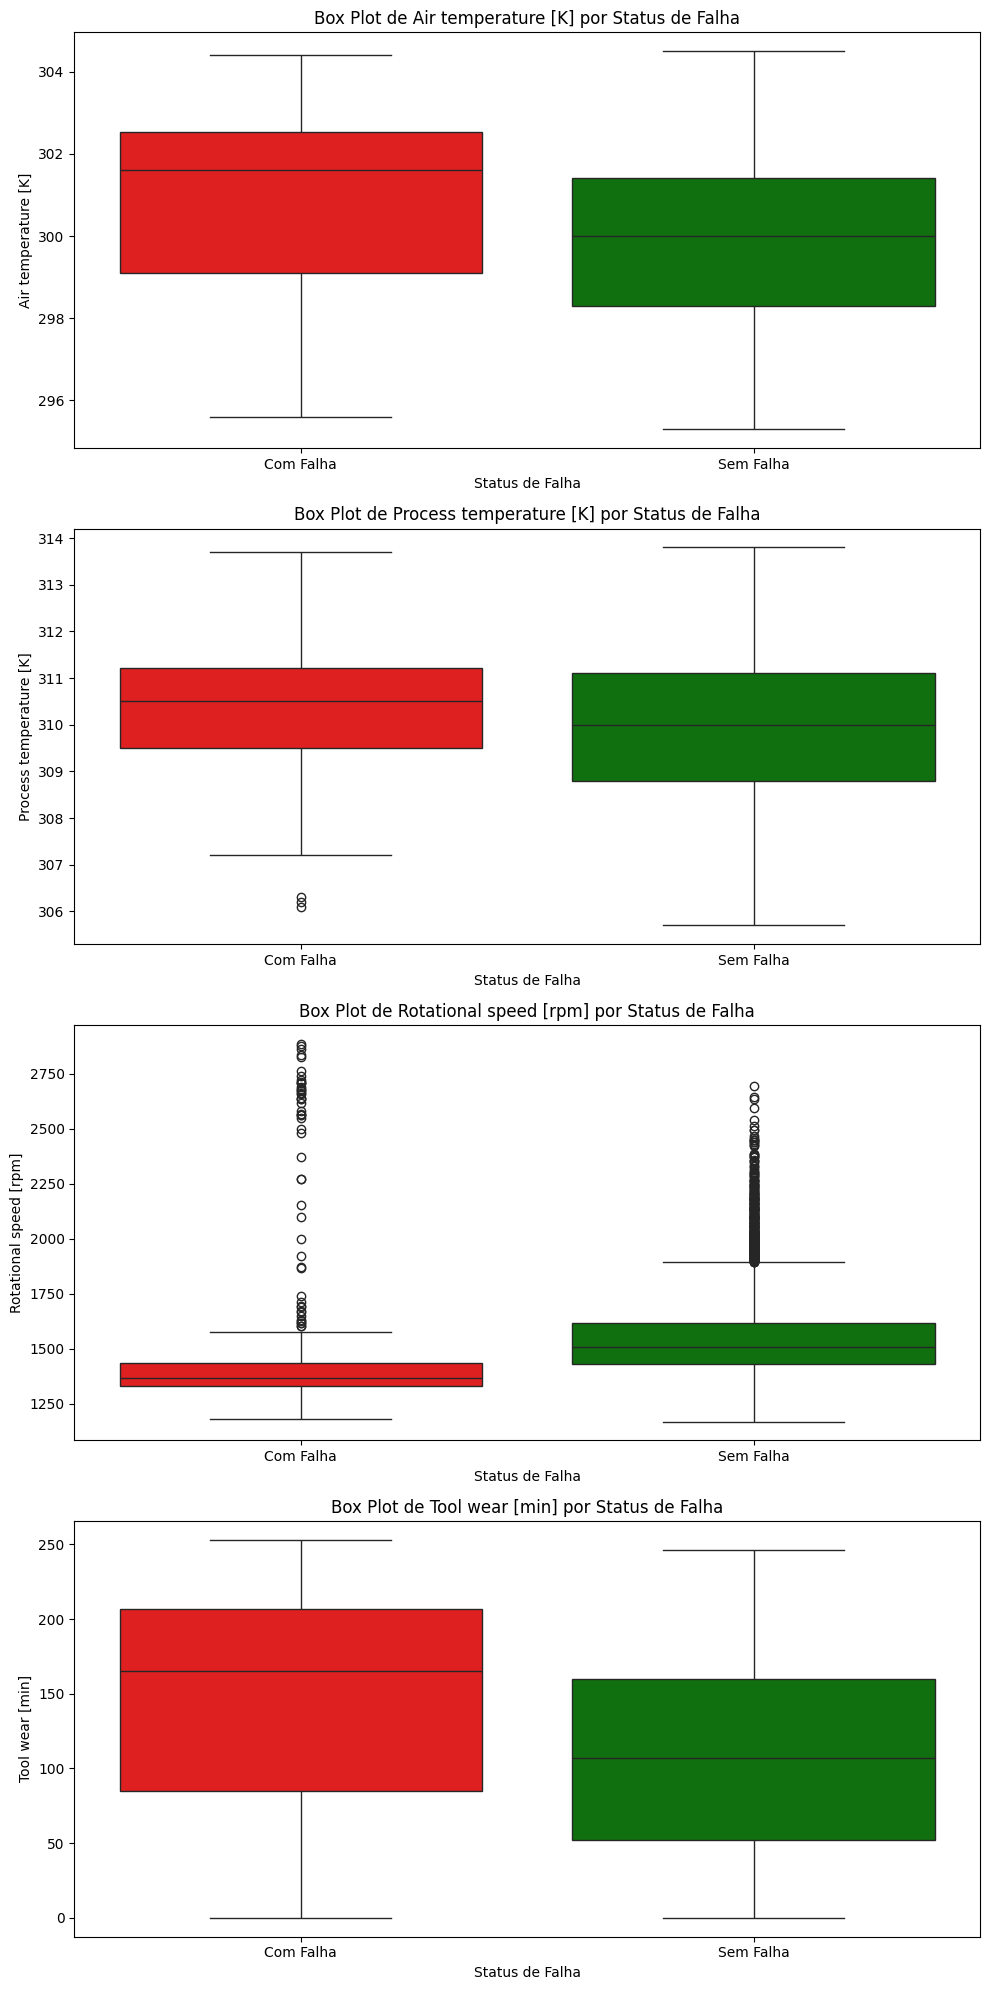

In [21]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Define numerical features for outlier analysis
numerical_features_for_outliers = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Tool wear [min]'
]

# Create a combined DataFrame for plotting
# Add a 'Failure Status' column to differentiate
failures_df_plot = failures_df[numerical_features_for_outliers].copy()
failures_df_plot['Failure Status'] = 'Com Falha'

no_failures_df_plot = no_failures_df[numerical_features_for_outliers].copy()
no_failures_df_plot['Failure Status'] = 'Sem Falha'

combined_df_outliers = pd.concat([failures_df_plot, no_failures_df_plot], ignore_index=True)

# Plotting box plots for outlier analysis
fig, axes = plt.subplots(len(numerical_features_for_outliers), 1, figsize=(10, 5 * len(numerical_features_for_outliers)))

for i, feature in enumerate(numerical_features_for_outliers):
    sns.boxplot(x='Failure Status', y=feature, data=combined_df_outliers, ax=axes[i], palette={'Com Falha': 'red', 'Sem Falha': 'green'})
    axes[i].set_title(f'Box Plot de {feature} por Status de Falha')
    axes[i].set_xlabel('Status de Falha')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

**5. Machine Learning**
---



In [20]:
# @title
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# Combine failures_df and no_failures_df to create a full dataset for ML
# First, add a 'Failure' target column (1 for failures, 0 for no failures)
failures_df_ml = failures_df.copy()
failures_df_ml['Failure'] = 1

no_failures_df_ml = no_failures_df.copy()
no_failures_df_ml['Failure'] = 0

full_df_ml = pd.concat([failures_df_ml, no_failures_df_ml], ignore_index=True)

# Define features (X) and target (y)
# Let's use the numerical features identified earlier
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = full_df_ml[features]
y = full_df_ml['Failure']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7000, 5)
Shape of X_test: (3000, 5)
Shape of y_train: (7000,)
Shape of y_test: (3000,)


In [19]:
# @title
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Acurácia do Modelo: {accuracy:.4f}")
print("\nRelatório de Classificação:")
print(report)

print("\nMatriz de Confusão:")
display(pd.DataFrame(conf_matrix, index=['Real Sem Falha', 'Real Com Falha'], columns=['Previsto Sem Falha', 'Previsto Com Falha']))

Acurácia do Modelo: 0.9670

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2896
           1       0.65      0.11      0.18       104

    accuracy                           0.97      3000
   macro avg       0.81      0.55      0.58      3000
weighted avg       0.96      0.97      0.96      3000


Matriz de Confusão:


,Previsto Sem Falha,Previsto Com Falha
Real Sem Falha,2890,6
Real Com Falha,93,11


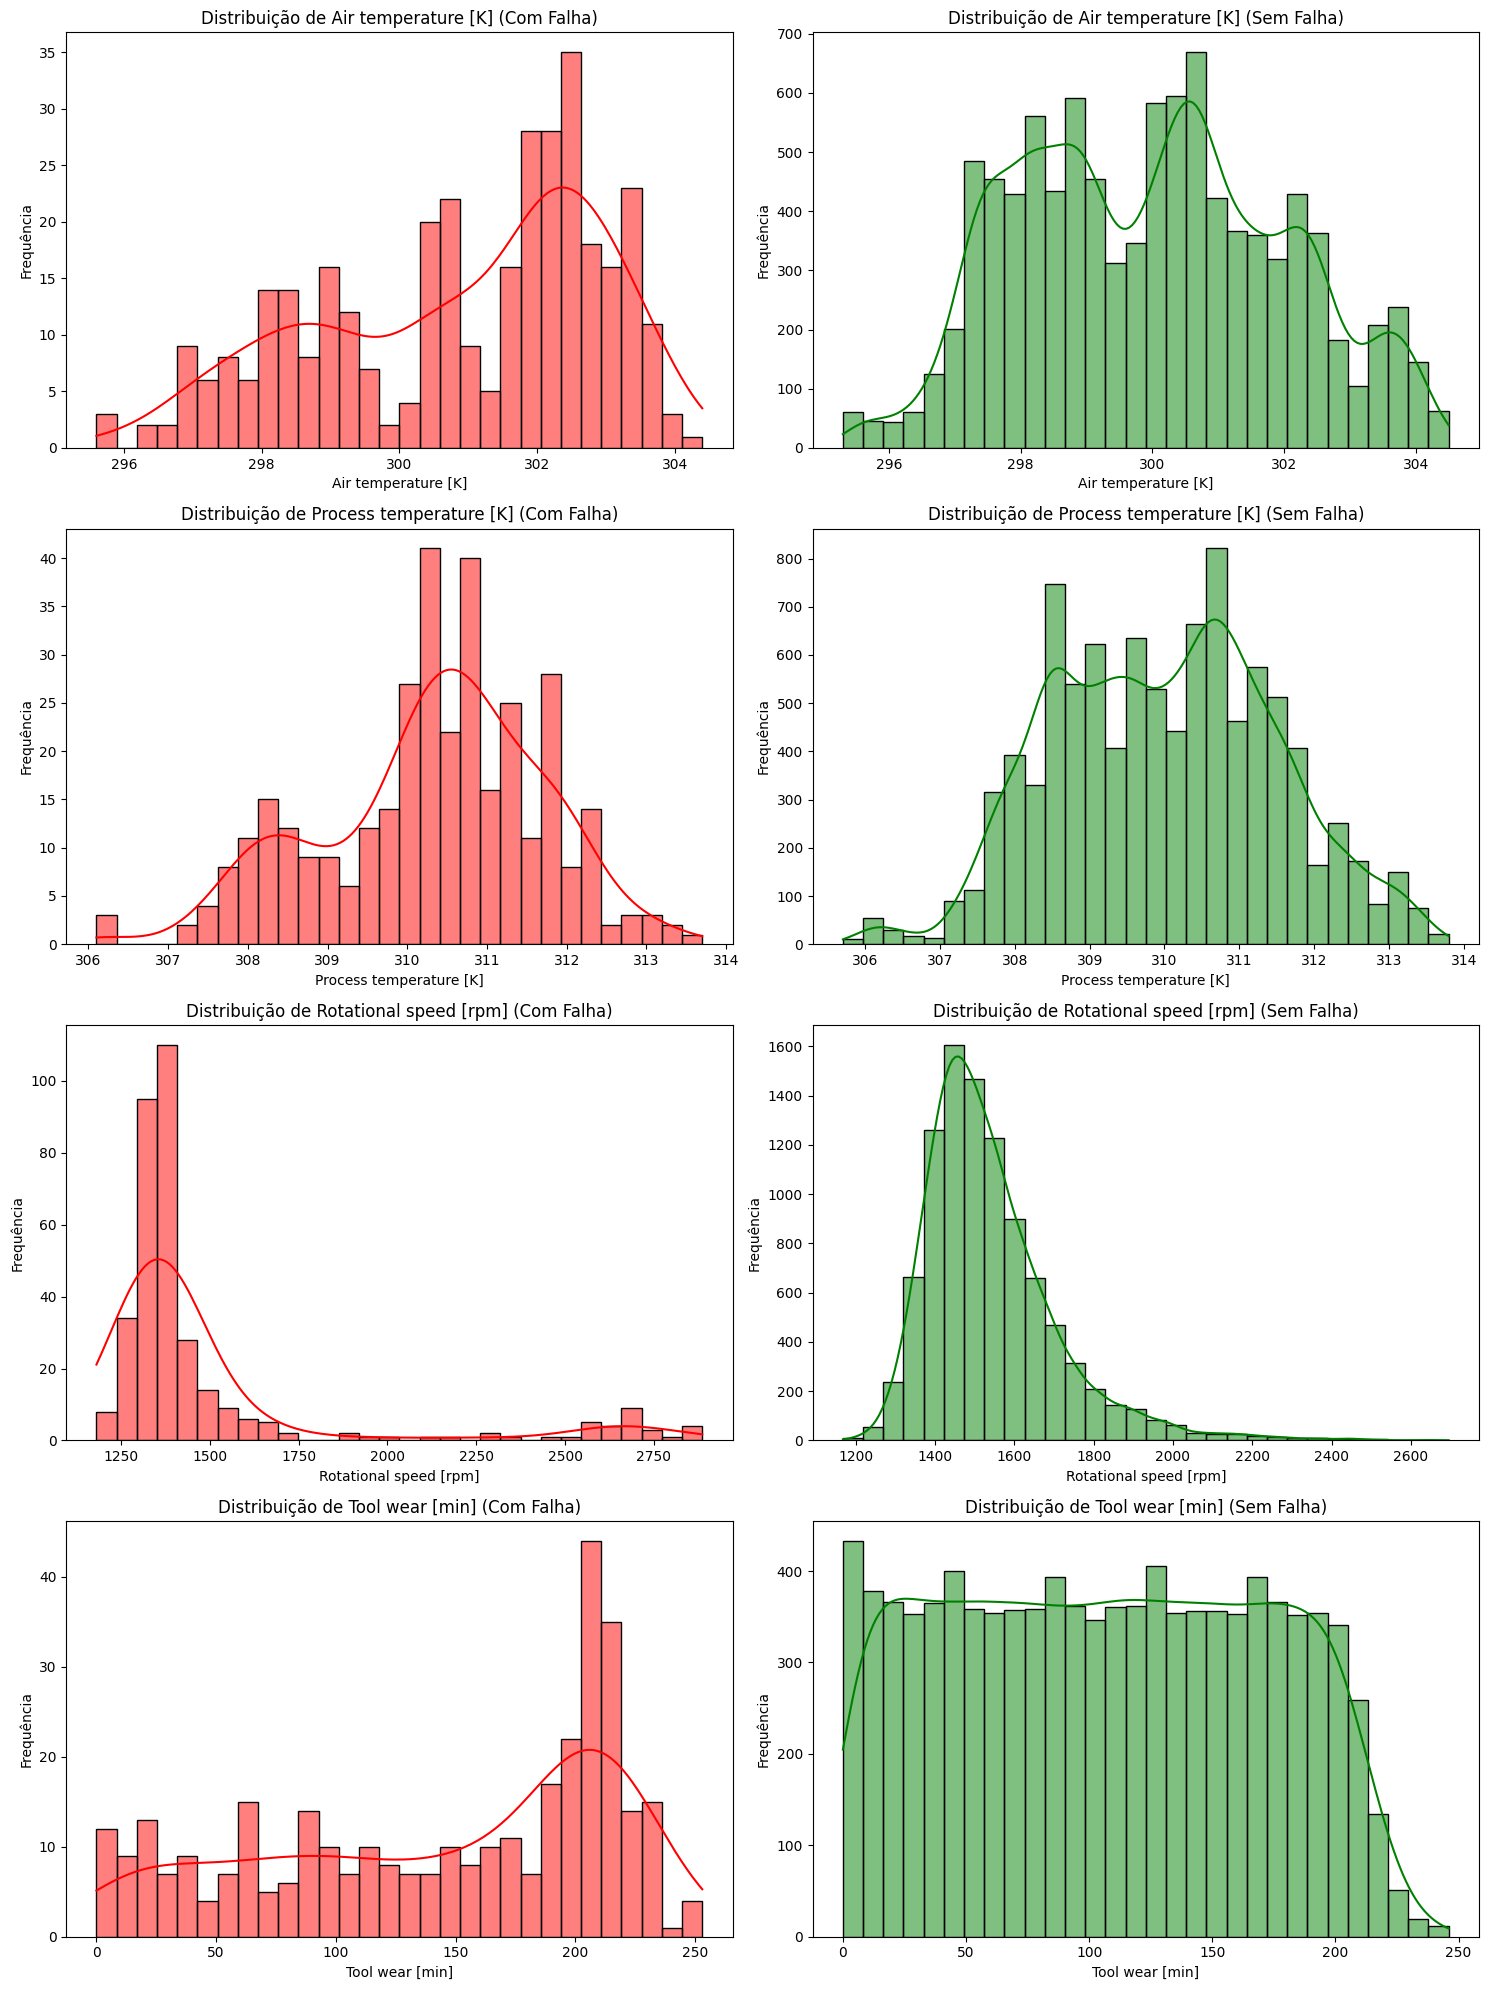

In [14]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Define numerical features for distribution analysis
numerical_features_for_distribution = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Tool wear [min]'
]

# Plotting histograms for distribution analysis
fig, axes = plt.subplots(len(numerical_features_for_distribution), 2, figsize=(15, 5 * len(numerical_features_for_distribution)))

for i, feature in enumerate(numerical_features_for_distribution):
    # Histogram for failures_df
    sns.histplot(failures_df[feature], kde=True, ax=axes[i, 0], color='red', bins=30)
    axes[i, 0].set_title(f'Distribuição de {feature} (Com Falha)')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frequência')

    # Histogram for no_failures_df
    sns.histplot(no_failures_df[feature], kde=True, ax=axes[i, 1], color='green', bins=30)
    axes[i, 1].set_title(f'Distribuição de {feature} (Sem Falha)')
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()